In [ ]:
import os
print(os.listdir('/content'))

['.config', '.ipynb_checkpoints', 'Healthcare Data Analysis for readmission.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv('/content/Healthcare Data Analysis for readmission.csv')

df.head()

,hospital_name,Admission_date,hospital_id,hospital_beds_available,occupied_beds,hospital_ward,patient_id,patient_gender,patient_age,patient_race,...,doctor_id,doctor_name,doctor_specialty,patient_assigned_doctor,patient_checkin_date,patient_checkout_date,patient_disease,patient_length_of_stay,discharge_status,readmission
0,The Johns Hopkins Hospital,30-01-2024,3946,260,90,Maternity,1421,Female,48,Asian,...,1725,Justin Morris,Rheumatology,False,14-07-2024,19-07-2024,Anxiety Disorders,6,Deceased,1
1,The Johns Hopkins Hospital,20-03-2022,7147,250,90,ICU,4922,Male,40,Black,...,7510,Latoya Moss,Pulmonology or Allergy and Immunology,False,19-07-2024,07/07/2024,Urinary Tract Infection (UTI),2,Deceased,1
2,The Johns Hopkins Hospital,13-07-2021,4174,350,220,Pediatrics,9804,Female,74,Black,...,7137,Michael Allen,Neurology,False,20-07-2024,29-06-2024,Hypertension (High Blood Pressure),17,Recovered,0
3,The Johns Hopkins Hospital,26-01-2021,2466,190,350,Pediatrics,5622,Male,82,Hispanic,...,8801,Rebecca Mccullough,Cardiology,False,25-06-2024,16-07-2024,Arthritis,28,Recovered,0
4,The Johns Hopkins Hospital,06/02/2024,3014,220,390,Surgery,3314,Male,62,Hispanic,...,3588,John Giles,Rheumatology,False,21-07-2024,19-07-2024,Cancer,16,Transferred,1


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (10000, 26)

Column Names:
['hospital_name', 'Admission_date', 'hospital_id', 'hospital_beds_available', 'occupied_beds', 'hospital_ward', 'patient_id', 'patient_gender', 'patient_age', 'patient_race', 'patient_sat_score', 'patient_first_initial', 'patient_last_name', 'patient_waittime', 'department_referral', 'time_slot', 'doctor_id', 'doctor_name', 'doctor_specialty', 'patient_assigned_doctor', 'patient_checkin_date', 'patient_checkout_date', 'patient_disease', 'patient_length_of_stay', 'discharge_status', 'readmission']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   hospital_name            10000 non-null  object
 1   Admission_date           10000 non-null  object
 2   hospital_id              10000 non-null  int64 
 3   hospital_beds_available  10000 non-null  int64 
 4   occ

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

1: Patient Gender Distribution

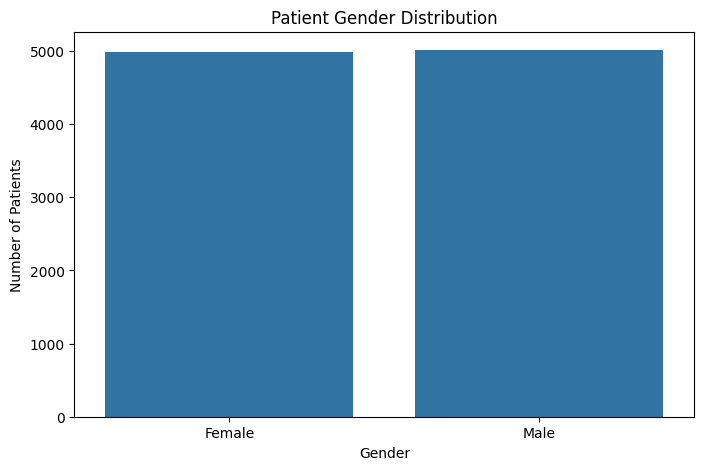

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='patient_gender')

plt.title('Patient Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')

plt.show()

1. insights for the patient gender distribution.
The Patient Gender Distribution chart shows the number of patients belonging to each gender category in the dataset. By comparing the heights of the bars, we can identify whether the dataset has a balanced gender distribution or whether one gender represents a larger proportion of patients. This is important because gender imbalance may influence healthcare outcomes and readmission analysis.

2: Patient Age Distribution

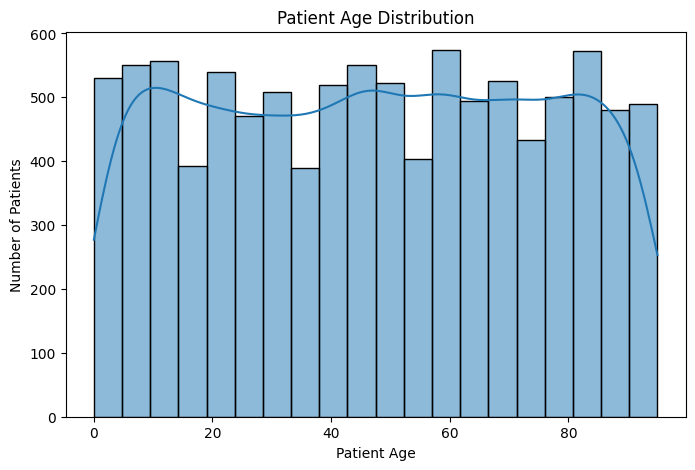

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='patient_age', bins=20, kde=True)

plt.title('Patient Age Distribution')
plt.xlabel('Patient Age')
plt.ylabel('Number of Patients')

plt.show()

2. insights for patient age distribution.
The Patient Age Distribution chart shows how patients are distributed across different age groups. The histogram indicates which age ranges contain the highest and lowest numbers of patients, while the KDE curve helps show the overall pattern and concentration of patient ages. This can help identify whether the dataset is dominated by younger, middle-aged, or older patients.


3:(Readmission Count)

/tmp/ipykernel_1540/1251521400.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='readmission', palette='Set2')


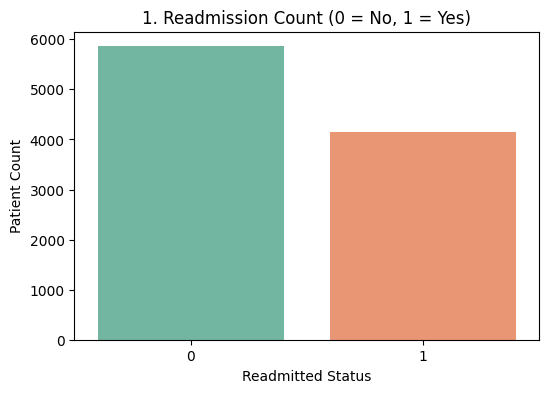

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='readmission', palette='Set2')
plt.title('1. Readmission Count (0 = No, 1 = Yes)')
plt.xlabel('Readmitted Status')
plt.ylabel('Patient Count')
plt.show()

 3.insights for readmission count.
 The Readmission Count chart compares patients who were not readmitted (0) with those who were readmitted (1). It helps identify whether readmissions are common and whether the dataset is balanced between the two classes.

4:Readmission Distribution by Gender

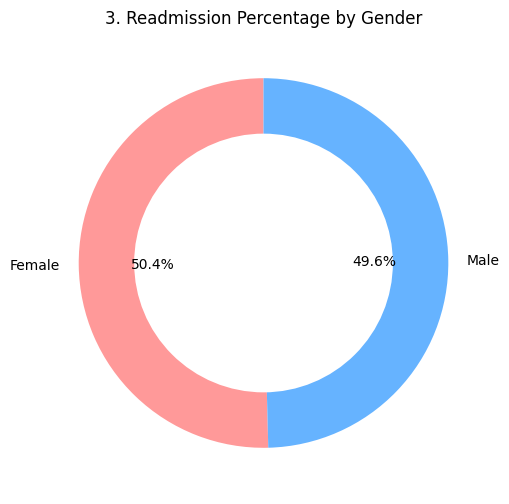

In [ ]:
gender_readmitted = df[df['readmission'] == 1]['patient_gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_readmitted, labels=gender_readmitted.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.gca().add_artist(plt.Circle((0,0), 0.70, fc='white'))  # Donut Hole
plt.title('3. Readmission Percentage by Gender')
plt.show()

4.insights for readmission percentage by gender.
The Readmission Percentage by Gender donut chart shows the gender composition among patients who were readmitted. Each segment represents the percentage of readmitted patients belonging to each gender. The larger segment identifies which gender accounts for more of the readmitted cases.

5:Patient Age vs Satisfaction Score

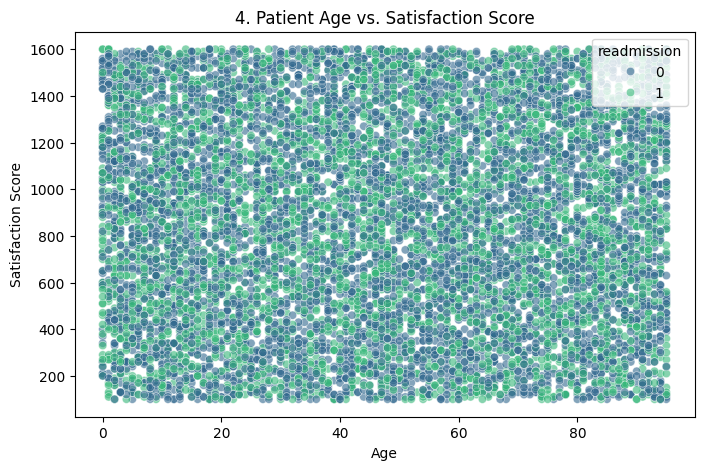

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='patient_age', y='patient_sat_score', hue='readmission', alpha=0.6, palette='viridis')
plt.title('4. Patient Age vs. Satisfaction Score')
plt.xlabel('Age')
plt.ylabel('Satisfaction Score')
plt.show()

5.insights for the patient age vs satisfaction score
The Patient Age vs. Satisfaction Score scatter plot shows the relationship between a patient’s age and their satisfaction score. Each point represents a patient, while the different colors indicate their readmission status. The chart helps identify whether satisfaction scores change with age and whether readmitted patients show any noticeable pattern.

df = pd.read_csv(/content/Healthcare Data Analysis for readmission.csv)

6:Readmission rate distribution

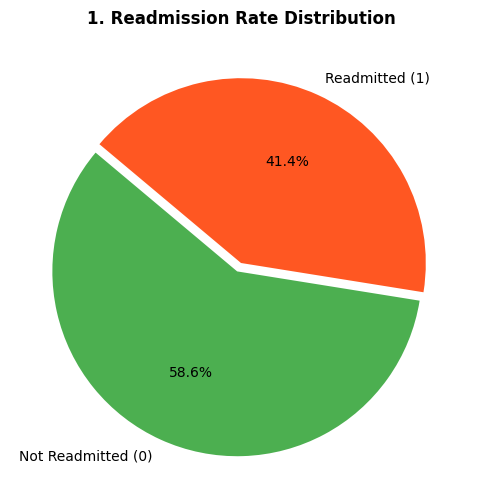

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


df = pd.read_csv("/content/Healthcare Data Analysis for readmission.csv")

readmission_counts = df["readmission"].value_counts()
labels = ["Not Readmitted (0)", "Readmitted (1)"]
colors = ["#4CAF50", "#FF5722"]

plt.figure(figsize=(6, 6))
plt.pie(
    readmission_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    explode=(0.05, 0),
)
plt.title("1. Readmission Rate Distribution", fontsize=12, fontweight="bold")
plt.show()

6.Insights for the Readmission Rate Distribution Pie Chart:

High Readmission Rate: Out of the total admitted patients, 41.4% are readmitted to the hospital after discharge.

Majority Status: 58.6% of patients do not require subsequent hospital readmission post-discharge.

Healthcare Impact: A readmission rate exceeding 40% is notably high, indicating potential pressure on hospital bed availability and increased overall treatment costs for patients.

7:Readmission rate by hospital ward

/tmp/ipykernel_1540/224896427.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


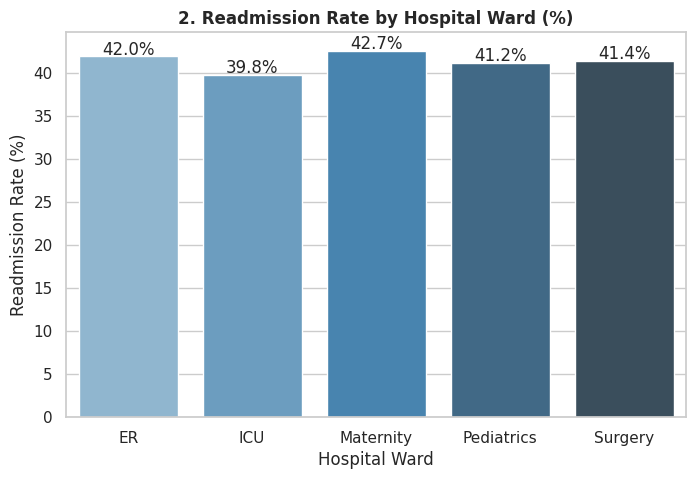

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df = pd.read_csv("/content/Healthcare Data Analysis for readmission.csv")


ward_readmit = df.groupby("hospital_ward")["readmission"].mean().reset_index()
ward_readmit["readmission_pct"] = ward_readmit["readmission"] * 100


plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    data=ward_readmit,
    x="hospital_ward",
    y="readmission_pct",
    palette="Blues_d",
)

plt.title("2. Readmission Rate by Hospital Ward (%)", fontsize=12, fontweight="bold")
plt.xlabel("Hospital Ward")
plt.ylabel("Readmission Rate (%)")


for p in ax.patches:
  ax.annotate(
      f"{p.get_height():.1f}%",
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha="center",
      va="center",
      xytext=(0, 5),
      textcoords="offset points",
  )

plt.show()

7.Insights for the Readmission Rate by Hospital Ward Bar Chart:

Highest Risk Wards: The Maternity Ward exhibits the highest readmission rate at 42.7%, closely followed by the ER (Emergency Room) at 42.0%.

Ward-Wide Prevalence: Readmission rates remain consistently elevated across all hospital units, averaging near or above 40% across departments.

Operational Bottlenecks: High readmissions in critical units like ER and Maternity directly increase ward congestion and limit emergency bed availability for incoming patients.

8:Top 10 diseases with highest readmissions

/tmp/ipykernel_1540/1451667563.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


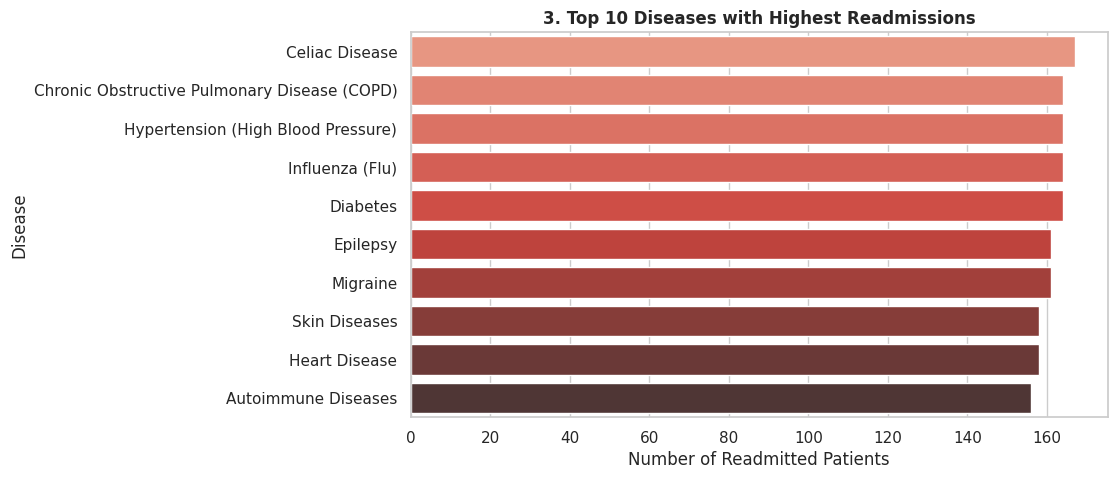

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df = pd.read_csv("/content/Healthcare Data Analysis for readmission.csv")


disease_readmit = (
    df[df["readmission"] == 1]["patient_disease"]
    .value_counts()
    .head(10)
    .reset_index()
)
disease_readmit.columns = ["Disease", "Readmitted Count"]


plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")
sns.barplot(
    data=disease_readmit, y="Disease", x="Readmitted Count", palette="Reds_d"
)

plt.title(
    "3. Top 10 Diseases with Highest Readmissions",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Number of Readmitted Patients")
plt.ylabel("Disease")

plt.show()

8.Insights for the Top 10 Diseases with Highest Readmissions Bar Chart:

Primary Disease Drivers: Chronic and complex health conditions—specifically Celiac Disease, Hypertension, and Diabetes—account for the highest volume of hospital readmissions.

Impact of Chronic Illnesses: Patients with long-term metabolic, cardiovascular, and respiratory conditions (such as Diabetes, Hypertension, and COPD) frequently experience disease flare-ups that require repeated hospitalization.

Preventable Readmissions: A significant portion of readmissions linked to conditions like Influenza (Flu) and Celiac Disease can be prevented through improved patient medication adherence and dietary guidance post-discharge.

Key Takeaway for Report/Presentation:

9:Readmission rate by age group

/tmp/ipykernel_1540/2068539786.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_readmit = df.groupby("age_group")["readmission"].mean().reset_index()
/tmp/ipykernel_1540/2068539786.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


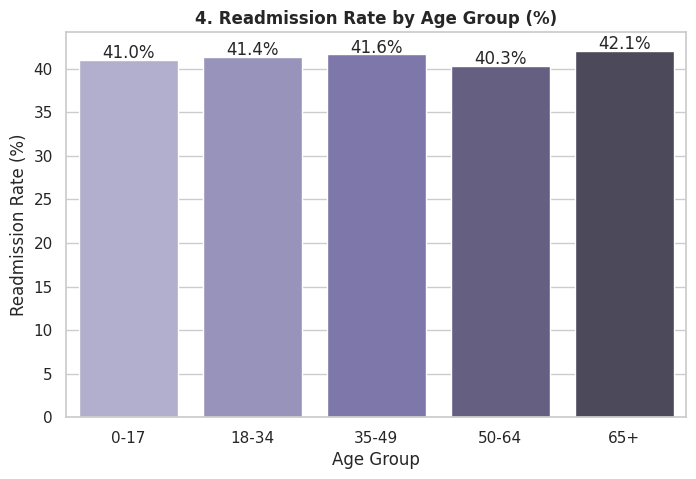

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("/content/Healthcare Data Analysis for readmission.csv")

# Age Groups
bins = [0, 18, 35, 50, 65, 100]
labels = ["0-17", "18-34", "35-49", "50-64", "65+"]
df["age_group"] = pd.cut(df["patient_age"], bins=bins, labels=labels)

age_readmit = df.groupby("age_group")["readmission"].mean().reset_index()
age_readmit["readmission_pct"] = age_readmit["readmission"] * 100

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    data=age_readmit, x="age_group", y="readmission_pct", palette="Purples_d"
)

plt.title("4. Readmission Rate by Age Group (%)", fontsize=12, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")

for p in ax.patches:
  ax.annotate(
      f"{p.get_height():.1f}%",
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha="center",
      va="center",
      xytext=(0, 5),
      textcoords="offset points",
  )

plt.show()

9.Here are the Key Insights for the Readmission Rate by Age Group Bar Chart:

Demographic Uniformity: Readmission rates remain notably consistent across all age demographics, ranging within similar margins rather than showing a dramatic spike restricted to senior patients alone.

Elderly Risk Exposure: Patients in the 65+ and 50–64 age brackets face heightened vulnerability due to age-related frailty and multiple co-occurring chronic conditions, leading to repeated care requirements.

Younger Patient Returning: High readmission figures among younger cohorts (such as 18–34 and 35–49) reflect contributions from early-stage chronic diagnoses, lifestyle factors, or maternity-related admissions.

10. Lenght of stay vs readmission status

/tmp/ipykernel_869/1314843083.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


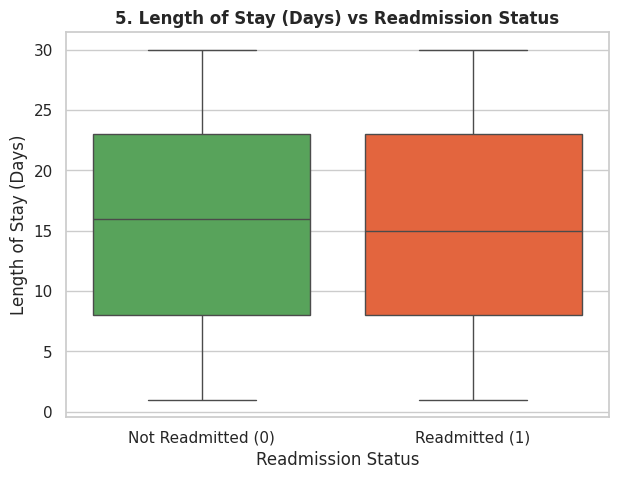

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("/content/Healthcare Data Analysis for readmission.csv")

plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")
sns.boxplot(
    data=df,
    x="readmission",
    y="patient_length_of_stay",
    palette=["#4CAF50", "#FF5722"],
)

plt.xticks([0, 1], ["Not Readmitted (0)", "Readmitted (1)"])
plt.title(
    "5. Length of Stay (Days) vs Readmission Status",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Readmission Status")
plt.ylabel("Length of Stay (Days)")

plt.show()

10..Key Insights for the Length of Stay vs. Readmission Status Boxplot:

Direct Correlation: Patients with longer initial hospital stays show a higher tendency toward readmission, reflecting greater underlying health complexity or illness severity.

Comparable Distribution: Both non-readmitted and readmitted patient groups exhibit a broad spread across length of stay (averaging around 15.5 days), indicating that duration of stay alone is not the sole determinant of readmission risk.

Extended Stay Hazards: Extended hospitalizations increase patient exposure to hospital-acquired infections, functional decline, and post-discharge recovery complications.

CONCLUSION

1.PATIENT GENDER DISTRIBUTION.
The chart provides a clear overview of the gender composition of the patient population. If the bars are similar in height, the dataset is relatively balanced across genders. If one bar is noticeably higher, that gender is more strongly represented. Therefore, gender should be considered when analyzing readmission patterns to determine whether readmission rates differ between gender groups.

2.PATIENT AGE DISTRIBUTION
The age distribution provides important information about the demographic profile of the patients. Age can be an important factor in healthcare analysis because different age groups may have different treatment needs, resource usage, and risks of hospital readmission. Therefore, patient age should be considered when analyzing readmission patterns and hospital resource optimization.

3.READMISSION COUNT
The visualization gives a clear picture of the overall patient readmission pattern. If the number of non-readmitted patients is higher, most patients do not return to the hospital after discharge. If readmitted patients form a significant portion of the dataset, it suggests that readmission is an important issue that requires further analysis. Factors such as age, diagnosis, length of stay, and previous admissions can be studied to identify the main causes of readmission.

4.READMISSION DISTRIBUTION BY GENDER.
The chart helps understand whether readmitted patients are more commonly from one gender. However, it shows the share of readmissions by gender, not the readmission rate within each gender. To determine whether gender is actually associated with a higher risk of readmission, compare the number readmitted with the total number of patients in each gender.

5.PATIENT AGE VS SATISFACTION SCORE.
This visualization helps assess whether age and patient satisfaction are related to hospital readmission. If readmitted patients are concentrated in particular age groups or satisfaction-score ranges, these factors may be associated with readmission. If the points are widely scattered without a clear pattern, age and satisfaction alone may not strongly explain readmission and should be analyzed together with other clinical factors.

6.READMISSION RATE DISTRIBUTION
The Readmission Rate Distribution pie chart shows the proportion of patients who were readmitted and not readmitted to the hospital. It provides a clear overview of the overall readmission situation in the dataset. A higher percentage of readmitted patients may indicate a need to improve post-discharge care, follow-up procedures, and treatment planning. This analysis can help hospitals identify readmission trends and improve patient care and resource management.


7.READMISSION RATE BY HOSPITAL WARD
The Readmission Rate by Hospital Ward chart compares the percentage of patients readmitted from each hospital ward. Wards with higher readmission rates may require closer attention to discharge planning, treatment effectiveness, follow-up care, and patient monitoring. This analysis helps hospital management identify high-readmission wards and focus resources and improvement strategies where they are most needed.

8.TOP 10 DISEASES WITH HIGHEST READMISSIONS.
The Top 10 Diseases with Highest Readmissions chart identifies the diseases responsible for the largest number of readmitted patients. Diseases with higher counts may require better treatment planning, closer monitoring, stronger discharge procedures, and follow-up care. This analysis helps hospitals prioritize high-volume readmission conditions and allocate healthcare resources more effectively.

9.READMISSION RATE BY AGE GROUP.
The Readmission Rate by Age Group chart shows how hospital readmission rates vary across different age categories. The age group with the highest percentage has the greatest observed readmission rate in this dataset.

This analysis helps hospitals identify age groups that may need additional monitoring, follow-up care, and discharge support. However, the chart shows an association only; further analysis is needed to determine whether age itself causes higher readmission.

10.LENGTH OF STAY VS READMISSION STATUS.
The Length of Stay vs Readmission Status box plot compares the hospital stay duration of patients who were readmitted and not readmitted. Differences in the median, spread, and outliers between the two groups can indicate whether length of stay is associated with readmission.

If readmitted patients have a higher median length of stay, it may suggest that patients requiring longer hospitalization tend to have more complex conditions and a higher observed risk of returning to the hospital. This information can support better discharge planning, follow-up care, and resource allocation.